In [1]:
import torch
import torch.nn as nn

# 1. ARCHITECTURE CONFIGURATION
# Tuple: (out_channels, kernel_size, stride)
# List: ["B", num_repeats] -> Residual Block
# "S": Scale Prediction (YOLO Head)
# "U": Upsampling
config = [
    (32, 3, 1),
    (64, 3, 2),
    ["B", 1],
    (128, 3, 2),
    ["B", 2],
    (256, 3, 2),
    ["B", 8],
    (512, 3, 2),
    ["B", 8],
    (1024, 3, 2),
    ["B", 4],
    (512, 1, 1),
    (1024, 3, 1),
    "S",
    (256, 1, 1),
    "U",
    (256, 1, 1),
    (512, 3, 1),
    "S",
    (128, 1, 1),
    "U",
    (128, 1, 1),
    (256, 3, 1),
    "S",
]

# 2. BASIC CONVOLUTIONAL BLOCK
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, bn_act=True, **kwargs):
        super().__init__()
        self.bn_act = bn_act
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            bias=not bn_act,
            **kwargs
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.leaky = nn.LeakyReLU(0.1)

    def forward(self, x):
        if self.bn_act:
            return self.leaky(self.bn(self.conv(x)))
        return self.conv(x)

# 3. RESIDUAL BLOCK (Darknet-53 style)
class ResidualBlock(nn.Module):
    def __init__(self, channels, use_residual=True, num_repeats=1):
        super().__init__()
        self.layers = nn.ModuleList()

        for _ in range(num_repeats):
            self.layers.append(
                nn.Sequential(
                    CNNBlock(channels, channels // 2, kernel_size=1),
                    CNNBlock(channels // 2, channels, kernel_size=3, padding=1),
                )
            )

        self.use_residual = use_residual
        self.num_repeats = num_repeats

    def forward(self, x):
        for layer in self.layers:
            if self.use_residual:
                x = x + layer(x)
            else:
                x = layer(x)
        return x

# 4. SCALE PREDICTION (YOLO HEAD)
class ScalePrediction(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.num_classes = num_classes
        self.pred = nn.Sequential(
            CNNBlock(in_channels, 2 * in_channels, kernel_size=3, padding=1),
            CNNBlock(
                2 * in_channels,
                (num_classes + 5) * 3,
                bn_act=False,
                kernel_size=1
            )
        )

    def forward(self, x):
        N, C, H, W = x.shape
        x = self.pred(x)
        x = x.reshape(N, 3, self.num_classes + 5, H, W)
        x = x.permute(0, 1, 3, 4, 2)
        return x

class YOLOv3(nn.Module):
    def __init__(self, in_channels=3, num_classes=8):
        super().__init__()
        self.num_classes = num_classes
        self.in_channels = in_channels
        self.layers = self._create_conv_layers()

    def forward(self, x):
        outputs = []
        route_connections = []

        for layer in self.layers:
            if isinstance(layer, ScalePrediction):
                outputs.append(layer(x))
                continue

            x = layer(x)

            if isinstance(layer, ResidualBlock) and layer.num_repeats == 8:
                route_connections.append(x)

            elif isinstance(layer, nn.Upsample):
                route = route_connections.pop()
                if route.shape[2:] != x.shape[2:]:
                    route = torch.nn.functional.interpolate(route, size=x.shape[2:], mode='nearest')

                x = torch.cat([x, route], dim=1)

        return outputs

    def _create_conv_layers(self):
        layers = nn.ModuleList()
        in_channels = self.in_channels

        for module in config:
            if isinstance(module, tuple):
                out_channels, kernel_size, stride = module

                layers.append(
                    CNNBlock(
                        in_channels,
                        out_channels,
                        kernel_size=kernel_size,
                        stride=stride,
                        padding=1 if kernel_size == 3 else 0
                    )
                )
                in_channels = out_channels

            elif isinstance(module, list):
                num_repeats = module[1]
                layers.append(
                    ResidualBlock(
                        in_channels,
                        num_repeats=num_repeats
                    )
                )

            elif isinstance(module, str):
                if module == "S":
                    layers.append(
                        ResidualBlock(
                            in_channels,
                            use_residual=False,
                            num_repeats=1
                        )
                    )

                    layers.append(
                        CNNBlock(
                            in_channels,
                            in_channels // 2,
                            kernel_size=1
                        )
                    )

                    layers.append(
                        ScalePrediction(
                            in_channels // 2,
                            self.num_classes
                        )
                    )

                    in_channels = in_channels // 2

                elif module == "U":
                    layers.append(nn.Upsample(scale_factor=2, mode="nearest"))
                    in_channels = in_channels * 3

        return layers

In [2]:
def train_fn(loader, model, optimizer, loss_fn, scaler, device, anchors):
    model.train()
    loop = tqdm(loader, leave=True, desc="Training")
    mean_loss = []

    optimizer.zero_grad()

    for batch_idx, (images, targets) in enumerate(loop):
        images = images.to(device)
        targets = [t.to(device) for t in targets]

        with torch.amp.autocast(device_type="cuda", enabled=(device == "cuda")):
            outputs = model(images)
            loss = loss_fn(outputs, targets, anchors)
            loss = loss / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (batch_idx + 1) % ACCUM_STEPS == 0 or (batch_idx + 1) == len(loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        mean_loss.append(loss.item() * ACCUM_STEPS)
        loop.set_postfix(loss=sum(mean_loss) / len(mean_loss))

    return sum(mean_loss) / len(mean_loss)

def save_checkpoint(model, optimizer, scheduler, scaler, filename, epoch, metrics_history=None):
    checkpoint = {
        "state_dict": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "epoch": epoch,
        "metrics_history": metrics_history if metrics_history is not None else {}
    }
    torch.save(checkpoint, filename)

def load_checkpoint(checkpoint_file, model, optimizer=None, scheduler=None, scaler=None):
    print("=> Loading Checkpoint")
    checkpoint = torch.load(checkpoint_file, map_location=DEVICE)

    model.load_state_dict(checkpoint["state_dict"])

    if optimizer is not None and "optimizer" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer"])

    if scheduler is not None and "scheduler" in checkpoint:
        optimizer_state = checkpoint["scheduler"]
        scheduler.load_state_dict(optimizer_state)

    if scaler is not None and "scaler" in checkpoint:
        scaler.load_state_dict(checkpoint["scaler"])

    last_epoch = checkpoint.get("epoch", 0) + 1
    metrics_history = checkpoint.get("metrics_history", {})

    return last_epoch, metrics_history

In [3]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class VisDroneDataset(Dataset):
    def __init__(self, img_dir, ann_dir, image_size=800):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.image_size = image_size
        self.images = sorted([f for f in os.listdir(img_dir) if f.endswith(".jpg")])

        # Valid VisDrone classes mapped to your 8-class setup
        self.valid_classes = [1, 2, 3, 4, 5, 6, 9, 10]
        self.class_map = {orig: i for i, orig in enumerate(self.valid_classes)}

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_path = os.path.join(self.img_dir, self.images[index])
        label_path = os.path.join(self.ann_dir, self.images[index].replace(".jpg", ".txt"))

        # Load image
        image = Image.open(img_path).convert("RGB")
        w_orig, h_orig = image.size

        # Letterbox resize
        scale = self.image_size / max(w_orig, h_orig)
        nw, nh = int(w_orig * scale), int(h_orig * scale)

        image_resized = image.resize((nw, nh), Image.Resampling.BICUBIC)
        new_image = Image.new("RGB", (self.image_size, self.image_size), (128, 128, 128))

        pad_x = (self.image_size - nw) // 2
        pad_y = (self.image_size - nh) // 2
        new_image.paste(image_resized, (pad_x, pad_y))

        # Load labels robustly
        bboxes = []
        if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
            with open(label_path, "r") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    try:
                        row = [float(x) for x in line.split(",")]
                    except ValueError:
                        continue  # skip malformed lines

                    orig_cls = int(row[5])
                    if orig_cls in self.valid_classes:
                        new_cls = self.class_map[orig_cls]

                        bw = (row[2] * scale) / self.image_size
                        bh = (row[3] * scale) / self.image_size
                        x_center = (row[0] * scale + pad_x + (row[2] * scale) / 2) / self.image_size
                        y_center = (row[1] * scale + pad_y + (row[3] * scale) / 2) / self.image_size

                        bboxes.append([new_cls, x_center, y_center, bw, bh])

        image_tensor = torch.from_numpy(np.array(new_image).transpose(2, 0, 1)).float() / 255.0
        bboxes_tensor = torch.tensor(bboxes) if bboxes else torch.zeros((0, 5))

        if bboxes_tensor.shape[0] > 0:
            bboxes_tensor[:, 0] = bboxes_tensor[:, 0].long()

        return image_tensor, bboxes_tensor

In [4]:
import torch
import torchvision.ops as ops
import numpy as np
import torch

def bbox_iou(box1, box2, eps=1e-6):
    # Convert to corners
    b1_x1 = box1[..., 0] - box1[..., 2] / 2
    b1_y1 = box1[..., 1] - box1[..., 3] / 2
    b1_x2 = box1[..., 0] + box1[..., 2] / 2
    b1_y2 = box1[..., 1] + box1[..., 3] / 2

    b2_x1 = box2[..., 0] - box2[..., 2] / 2
    b2_y1 = box2[..., 1] - box2[..., 3] / 2
    b2_x2 = box2[..., 0] + box2[..., 2] / 2
    b2_y2 = box2[..., 1] + box2[..., 3] / 2

    # Intersection
    inter_x1 = torch.max(b1_x1, b2_x1)
    inter_y1 = torch.max(b1_y1, b2_y1)
    inter_x2 = torch.min(b1_x2, b2_x2)
    inter_y2 = torch.min(b1_y2, b2_y2)

    inter_area = torch.clamp(inter_x2 - inter_x1, min=0) * torch.clamp(inter_y2 - inter_y1, min=0)

    box1_area = box1[..., 2] * box1[..., 3]
    box2_area = box2[..., 2] * box2[..., 3]

    iou = inter_area / (box1_area + box2_area - inter_area + eps)
    return iou

def get_nms_predictions(outputs, batch_idx, anchors, conf_thresh=0.25, iou_thresh=0.45):
    raw_preds = []

    for scale_idx, out in enumerate(outputs):
        # out: [Batch, Anchors, S, S, 5+Classes]
        S = out.shape[2]
        obj_probs = torch.sigmoid(out[batch_idx, ..., 4])
        class_probs = torch.softmax(out[batch_idx, ..., 5:], dim=-1)
        boxes = out[batch_idx, ..., 0:4]

        mask = obj_probs > conf_thresh
        if mask.any():
            indices = mask.nonzero()
            for idx in indices:
                a, j, i = idx[0], idx[1], idx[2]
                conf, cls_idx = torch.max(class_probs[a, j, i], dim=-1)
                score = (obj_probs[a, j, i] * conf).item()

                # IMPORTANT: YOLO stores offsets. We convert to 0-1 global coords
                tx, ty, tw, th = boxes[a, j, i]
                tw = torch.clamp(tw, -10, 10)
                th = torch.clamp(th, -10, 10)

                anchor_w, anchor_h = anchors[scale_idx][a]

                x = (torch.sigmoid(tx) + i) / S
                y = (torch.sigmoid(ty) + j) / S
                w = anchor_w * torch.exp(torch.clamp(tw, -10, 10))
                h = anchor_h * torch.exp(torch.clamp(th, -10, 10))

                raw_preds.append([x.item(), y.item(), w.item(), h.item(), score, cls_idx.item()])

    if not raw_preds:
        return []

    device = outputs[0].device
    preds_tensor = torch.tensor(raw_preds, dtype=torch.float32, device=device)

    boxes = torch.stack([
        preds_tensor[:, 0] - preds_tensor[:, 2] / 2,
        preds_tensor[:, 1] - preds_tensor[:, 3] / 2,
        preds_tensor[:, 0] + preds_tensor[:, 2] / 2,
        preds_tensor[:, 1] + preds_tensor[:, 3] / 2
    ], dim=1)

    scores = preds_tensor[:, 4]
    class_labels = preds_tensor[:, 5]

    keep_idx = ops.batched_nms(boxes, scores, class_labels, iou_threshold=iou_thresh)

    return preds_tensor[keep_idx].tolist()

def calculate_ap(recalls, precisions):
    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([1.0], precisions, [0.0]))
    mpre = np.flip(np.maximum.accumulate(np.flip(mpre)))
    indices = np.where(mrec[1:] != mrec[:-1])[0]
    return np.sum((mrec[indices + 1] - mrec[indices]) * mpre[indices + 1])

def final_evaluation(loader, model, anchors, conf_thresh=0.01, iou_thresh=0.45):
    model.eval()
    all_preds = []
    all_targets = []
    device = next(model.parameters()).device

    print("=> Running Evaluation...")

    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(loader):
            images = images.to(device)
            outputs = model(images)

            for b in range(images.shape[0]):
                # 1. Get NMS predictions for this image
                # Returns list of [x, y, w, h, score, class_id] in 0-1 range
                preds = get_nms_predictions(outputs, b, anchors, conf_thresh, iou_thresh)

                # 2. Convert to [x1, y1, x2, y2, score, class_id]
                for p in preds:
                    x1, y1 = p[0] - p[2] / 2, p[1] - p[3] / 2
                    x2, y2 = p[0] + p[2] / 2, p[1] + p[3] / 2
                    all_preds.append([batch_idx * loader.batch_size + b, p[5], p[4], x1, y1, x2, y2])

                # 3. Store Ground Truth: [img_idx, class, x1, y1, x2, y2]
                gt_boxes = targets[b]
                for gt in gt_boxes:
                    c, x, y, w, h = gt.tolist()
                    x1, y1 = x - w / 2, y - h / 2
                    x2, y2 = x + w / 2, y + h / 2
                    all_targets.append([batch_idx * loader.batch_size + b, c, x1, y1, x2, y2])

    # Convert to arrays for faster processing
    all_preds = np.array(all_preds) if all_preds else np.empty((0, 7))
    all_targets = np.array(all_targets) if all_targets else np.empty((0, 6))

    iou_thresholds = np.linspace(0.5, 0.95, 10)
    map_list = []

    # Calculate AP for each IoU threshold
    for iou_thr in iou_thresholds:
        aps = []

        for c in range(NUM_CLASSES):
            # Get preds and targets for this specific class
            cls_preds = all_preds[all_preds[:, 1] == c]
            cls_targets = all_targets[all_targets[:, 1] == c]

            if len(cls_targets) == 0:
                continue
            if len(cls_preds) == 0:
                aps.append(0)
                continue

            # Sort predictions by score descending
            cls_preds = cls_preds[cls_preds[:, 2].argsort()[::-1]]

            tp = np.zeros(len(cls_preds))
            fp = np.zeros(len(cls_preds))

            # Map to keep track of matched GTs per image
            matched_gts = {img_idx: set() for img_idx in np.unique(cls_targets[:, 0])}

            for i, p in enumerate(cls_preds):
                img_idx = p[0]
                best_iou = 0
                best_gt_idx = -1

                # Find best matching GT in the same image
                img_gts = cls_targets[cls_targets[:, 0] == img_idx]
                for g_idx, g in enumerate(img_gts):
                    iou = calculate_single_iou(p[3:], g[2:])
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = g_idx

                if best_iou >= iou_thr and best_gt_idx not in matched_gts[img_idx]:
                    tp[i] = 1
                    matched_gts[img_idx].add(best_gt_idx)
                else:
                    fp[i] = 1

            # Compute Precision-Recall
            tp_cumsum = np.cumsum(tp)
            fp_cumsum = np.cumsum(fp)

            recalls = tp_cumsum / len(cls_targets)
            precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-6)

            aps.append(calculate_ap(recalls, precisions))

        map_list.append(np.mean(aps) if aps else 0)

    model.train()
    return {
        "map50": map_list[0],
        "map50_95": np.mean(map_list)
    }

def calculate_single_iou(box1, box2):
    """Simple IoU for evaluation: [x1, y1, x2, y2]"""
    inter_x1 = max(box1[0], box2[0])
    inter_y1 = max(box1[1], box2[1])
    inter_x2 = min(box1[2], box2[2])
    inter_y2 = min(box1[3], box2[3])

    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    return inter_area / (area1 + area2 - inter_area + 1e-6)

def check_class_performance(loader, model, anchors, threshold=0.3, max_batches=3):
    model.eval()
    device = next(model.parameters()).device

    # Initialize counters for this evaluation run
    tp = 0
    fp = 0
    total_gt = 0

    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(loader):
            if batch_idx >= max_batches:
                break

            images = images.to(device)
            outputs = model(images)

            for b in range(images.shape[0]):
                # 1. Get NMS predictions: [x_mid, y_mid, w, h, score, class]
                preds = get_nms_predictions(outputs, b, anchors, conf_thresh=threshold)

                # 2. Get Ground Truth for this image: [class, x_mid, y_mid, w, h]
                gt_boxes = targets[b].to(device)
                num_gt = gt_boxes.shape[0]
                total_gt += num_gt

                if len(preds) == 0:
                    continue

                if num_gt == 0:
                    fp += len(preds)
                    continue

                # 3. Convert GT from [midpoints] to [corners] for IOU: [x1, y1, x2, y2]
                gt_corners = torch.zeros((num_gt, 4), device=device)
                gt_corners[:, 0] = gt_boxes[:, 1] - gt_boxes[:, 3] / 2
                gt_corners[:, 1] = gt_boxes[:, 2] - gt_boxes[:, 4] / 2
                gt_corners[:, 2] = gt_boxes[:, 1] + gt_boxes[:, 3] / 2
                gt_corners[:, 3] = gt_boxes[:, 2] + gt_boxes[:, 4] / 2

                # Track which GT boxes have already been "claimed" by a prediction
                used_gt = torch.zeros(num_gt, device=device)

                # 4. Match Predictions to GT
                for p in preds:
                    # Convert Pred from [midpoints] to [corners]
                    p_corner = torch.tensor([
                        p[0] - p[2] / 2, p[1] - p[3] / 2,
                        p[0] + p[2] / 2, p[1] + p[3] / 2
                    ], device=device).unsqueeze(0)

                    # Calculate IOU against all GT boxes in this image
                    ious = ops.box_iou(p_corner, gt_corners).squeeze(0)
                    best_iou, best_idx = ious.max(0)

                    # A True Positive requires:
                    # High IOU + Class Match + GT not already claimed
                    if (best_iou > 0.5 and p[5] == gt_boxes[best_idx, 0] and used_gt[best_idx] == 0):
                        tp += 1
                        used_gt[best_idx] = 1
                    else:
                        fp += 1

    # Final Metric Calculation
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (total_gt + 1e-6)

    model.train()
    return precision, recall

In [5]:
import torch
import torch.nn as nn

class YoloLoss(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.mse = nn.MSELoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.ce = nn.CrossEntropyLoss()

        self.lambda_class = 1.0
        self.lambda_noobj = 0.5
        self.lambda_obj = 1.0
        self.lambda_box = 10.0

        self.num_classes = num_classes

    def forward(self, predictions, targets, anchors):
        device = predictions[0].device
        batch_size = predictions[0].shape[0]

        # Create target tensors for all 3 scales first
        obj_targets = []
        ignore_masks = []
        box_targets = []
        cls_targets = []

        for p in predictions:
            N, A, S, _, _ = p.shape
            obj_targets.append(torch.zeros((N, A, S, S), device=device))
            ignore_masks.append(torch.zeros((N, A, S, S), device=device))
            box_targets.append(torch.zeros((N, A, S, S, 4), device=device))
            cls_targets.append(torch.zeros((N, A, S, S), dtype=torch.long, device=device))

        # Flatten all 9 anchors so each GT is assigned ONLY ONCE globally
        all_anchors = torch.cat([a.to(device) for a in anchors], dim=0)  # [9, 2]

        for b in range(batch_size):
            if len(targets[b]) == 0:
                continue

            for label in targets[b]:
                c, x, y, w, h = label
                gt_wh = torch.tensor([w, h], device=device)

                # IoU between GT WH and all 9 anchors
                inter = torch.min(gt_wh[0], all_anchors[:, 0]) * torch.min(gt_wh[1], all_anchors[:, 1])
                union = gt_wh[0] * gt_wh[1] + all_anchors[:, 0] * all_anchors[:, 1] - inter
                anchor_ious = inter / (union + 1e-6)

                best_anchor = torch.argmax(anchor_ious).item()
                best_scale = best_anchor // 3
                best_anchor_in_scale = best_anchor % 3

                # Mark high-IoU non-best anchors as ignore for anchor_idx_global, iou_val in enumerate(anchor_ious)
                for anchor_idx_global, iou_val in enumerate(anchor_ious):
                    if anchor_idx_global == best_anchor:
                        continue
                    if iou_val > 0.5:
                        scale_idx = anchor_idx_global // 3
                        anchor_idx = anchor_idx_global % 3
                        S = predictions[scale_idx].shape[2]

                        i = int(torch.clamp(x * S, 0, S - 1).item())
                        j = int(torch.clamp(y * S, 0, S - 1).item())
                        ignore_masks[scale_idx][b, anchor_idx, j, i] = 1

                # Assign GT only to best anchor/scale
                S = predictions[best_scale].shape[2]
                i = int(torch.clamp(x * S, 0, S - 1).item())
                j = int(torch.clamp(y * S, 0, S - 1).item())

                obj_targets[best_scale][b, best_anchor_in_scale, j, i] = 1

                anchor_w, anchor_h = anchors[best_scale][best_anchor_in_scale].to(device)

                tx = x * S - i
                ty = y * S - j
                tw = torch.log(w / (anchor_w + 1e-6) + 1e-6)
                th = torch.log(h / (anchor_h + 1e-6) + 1e-6)

                box_targets[best_scale][b, best_anchor_in_scale, j, i] = torch.tensor(
                    [tx, ty, tw, th], device=device
                )
                cls_targets[best_scale][b, best_anchor_in_scale, j, i] = int(c)

        total_loss = 0.0

        for scale_idx, p in enumerate(predictions):
            obj = obj_targets[scale_idx]
            ignore = ignore_masks[scale_idx]
            box = box_targets[scale_idx]
            cls = cls_targets[scale_idx]

            obj_mask = obj == 1
            noobj_mask = (obj == 0) & (ignore == 0)

            pred_obj = p[..., 4]

            if obj_mask.any():
                loss_obj = self.bce(pred_obj[obj_mask], obj[obj_mask])
            else:
                loss_obj = torch.tensor(0.0, device=device)

            # Sample no-object cells to save memory
            noobj_indices = noobj_mask.nonzero(as_tuple=False)
            if noobj_indices.shape[0] > 0:
                max_noobj = min(noobj_indices.shape[0], 50000)  # tune if needed
                if noobj_indices.shape[0] > max_noobj:
                    perm = torch.randperm(noobj_indices.shape[0], device=device)[:max_noobj]
                    noobj_indices = noobj_indices[perm]

                pred_noobj = pred_obj[
                    noobj_indices[:, 0],
                    noobj_indices[:, 1],
                    noobj_indices[:, 2],
                    noobj_indices[:, 3]
                ]
                target_noobj = obj[
                    noobj_indices[:, 0],
                    noobj_indices[:, 1],
                    noobj_indices[:, 2],
                    noobj_indices[:, 3]
                ]
                loss_noobj = self.bce(pred_noobj, target_noobj)
            else:
                loss_noobj = torch.tensor(0.0, device=device)

            # Box + class loss
            if obj_mask.any():
                pred_boxes = p[..., 0:4][obj_mask]
                target_boxes = box[obj_mask]

                pred_xy = pred_boxes[..., 0:2]
                pred_wh = pred_boxes[..., 2:4]

                target_xy = target_boxes[..., 0:2]
                target_wh = target_boxes[..., 2:4]

                loss_xy = self.bce(pred_xy, target_xy)
                loss_wh = self.mse(pred_wh, target_wh)
                loss_box = loss_xy + loss_wh

                loss_cls = self.ce(p[..., 5:][obj_mask], cls[obj_mask])
            else:
                loss_box = torch.tensor(0.0, device=device)
                loss_cls = torch.tensor(0.0, device=device)

            total_loss += (
                self.lambda_box * loss_box +
                self.lambda_obj * loss_obj +
                self.lambda_noobj * loss_noobj +
                self.lambda_class * loss_cls
            )

        return total_loss / batch_size

In [6]:
def yolo_collate_fn(batch):
    images = []
    targets = []

    for img, boxes in batch:
        images.append(img)

        # Ensure boxes are float tensors and on the right device
        if boxes.numel() == 0:
            boxes = torch.zeros((0, 5), dtype=torch.float32)
        else:
            boxes = boxes.float()

        targets.append(boxes)

    images = torch.stack(images, dim=0)
    return images, targets

In [7]:
def evaluate_and_collect_metrics(loader, model, anchors, conf_thresh=0.25, iou_thresh=0.45, max_batches=5):
    model.eval()
    device = next(model.parameters()).device

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(loader):
            if max_batches is not None and batch_idx >= max_batches:
                break

            images = images.to(device)
            outputs = model(images)

            for b in range(images.shape[0]):
                preds = get_nms_predictions(outputs, b, anchors, conf_thresh=conf_thresh, iou_thresh=iou_thresh)

                for p in preds:
                    x1, y1 = p[0] - p[2] / 2, p[1] - p[3] / 2
                    x2, y2 = p[0] + p[2] / 2, p[1] + p[3] / 2
                    all_preds.append([batch_idx * loader.batch_size + b, p[5], p[4], x1, y1, x2, y2])

                gt_boxes = targets[b]
                for gt in gt_boxes:
                    c, x, y, w, h = gt.tolist()
                    x1, y1 = x - w / 2, y - h / 2
                    x2, y2 = x + w / 2, y + h / 2
                    all_targets.append([batch_idx * loader.batch_size + b, c, x1, y1, x2, y2])

    all_preds = np.array(all_preds) if all_preds else np.empty((0, 7))
    all_targets = np.array(all_targets) if all_targets else np.empty((0, 6))

    iou_thresholds = np.linspace(0.5, 0.95, 10)
    map_list = []

    total_tp = 0
    total_fp = 0
    total_fn = 0

    for iou_thr in iou_thresholds:
        aps = []

        for c in range(NUM_CLASSES):
            cls_preds = all_preds[all_preds[:, 1] == c]
            cls_targets = all_targets[all_targets[:, 1] == c]

            if len(cls_targets) == 0:
                continue
            if len(cls_preds) == 0:
                aps.append(0)
                if iou_thr == 0.5:
                    total_fn += len(cls_targets)
                continue

            cls_preds = cls_preds[cls_preds[:, 2].argsort()[::-1]]

            tp = np.zeros(len(cls_preds))
            fp = np.zeros(len(cls_preds))

            matched_gts = {img_idx: set() for img_idx in np.unique(cls_targets[:, 0])}

            for i, p in enumerate(cls_preds):
                img_idx = p[0]
                best_iou = 0
                best_gt_idx = -1

                img_gts = cls_targets[cls_targets[:, 0] == img_idx]
                for g_idx, g in enumerate(img_gts):
                    iou = calculate_single_iou(p[3:], g[2:])
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = g_idx

                if best_iou >= iou_thr and best_gt_idx not in matched_gts[img_idx]:
                    tp[i] = 1
                    matched_gts[img_idx].add(best_gt_idx)
                else:
                    fp[i] = 1

            tp_cumsum = np.cumsum(tp)
            fp_cumsum = np.cumsum(fp)

            recalls = tp_cumsum / (len(cls_targets) + 1e-6)
            precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-6)

            aps.append(calculate_ap(recalls, precisions))

            # only compute precision/recall/accuracy-style stats once at IoU=0.5
            if iou_thr == 0.5:
                class_tp = tp.sum()
                class_fp = fp.sum()
                class_fn = max(0, len(cls_targets) - class_tp)

                total_tp += class_tp
                total_fp += class_fp
                total_fn += class_fn

        map_list.append(np.mean(aps) if aps else 0)

    precision = total_tp / (total_tp + total_fp + 1e-6)
    recall = total_tp / (total_tp + total_fn + 1e-6)

    # detection accuracy-style metric
    accuracy = total_tp / (total_tp + total_fp + total_fn + 1e-6)

    model.train()
    return {
        "map50": float(map_list[0]),
        "map50_95": float(np.mean(map_list)),
        "precision": float(precision),
        "recall": float(recall),
        "accuracy": float(accuracy),
    }

In [8]:
import csv

def save_metrics_to_csv(metrics_history, csv_file):
    with open(csv_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["epoch", "train_loss", "map50", "map50_95", "precision", "recall", "accuracy"])

        num_rows = len(metrics_history["epoch"])
        for i in range(num_rows):
            writer.writerow([
                metrics_history["epoch"][i],
                metrics_history["train_loss"][i],
                metrics_history["map50"][i],
                metrics_history["map50_95"][i],
                metrics_history["precision"][i],
                metrics_history["recall"][i],
                metrics_history["accuracy"][i],
            ])

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import os
import numpy as np
from PIL import Image
from torch.optim.lr_scheduler import CosineAnnealingLR

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 8
IMAGE_SIZE = 1280
BATCH_SIZE = 4
ACCUM_STEPS = 4
LEARNING_RATE = 5e-5
NUM_EPOCHS = 353
LOAD_MODEL = True
CHECKPOINT_FILE = "/home/zkelias/VisDrone/checkpoint.pth.tar"
METRICS_CSV_FILE = "/home/zkelias/VisDrone/metrics_history.csv"

def main():
    model = YOLOv3(num_classes=8).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-4
    )

    scheduler = CosineAnnealingLR(
        optimizer,
        T_max=NUM_EPOCHS,
        eta_min=1e-6
    )

    loss_fn = YoloLoss(num_classes=8)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

    anchors = torch.tensor([
        [(0.0771, 0.0679), (0.05, 0.0293), (0.0281, 0.0407)],
        [(0.0279, 0.0164), (0.0157, 0.0257), (0.0093, 0.0179)],
        [(0.015, 0.0105), (0.0064, 0.01), (0.0036, 0.0057)]
    ], dtype=torch.float32).to(DEVICE)

    train_dataset = VisDroneDataset(
        img_dir="/home/zkelias/VisDrone Data/train/images/",
        ann_dir="/home/zkelias/VisDrone Data/train/annotations/",
        image_size=IMAGE_SIZE
    )

    val_dataset = VisDroneDataset(
        img_dir="/home/zkelias/VisDrone Data/val/images/",
        ann_dir="/home/zkelias/VisDrone Data/val/annotations/",
        image_size=IMAGE_SIZE
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=False,
        persistent_workers=False,
        collate_fn=yolo_collate_fn
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
        persistent_workers=False,
        collate_fn=yolo_collate_fn
    )

    metrics_history = {
        "epoch": [],
        "train_loss": [],
        "map50": [],
        "map50_95": [],
        "precision": [],
        "recall": [],
        "accuracy": [],
    }

    start_epoch = 0
    if LOAD_MODEL and os.path.exists(CHECKPOINT_FILE):
        start_epoch, loaded_history = load_checkpoint(
            CHECKPOINT_FILE, model, optimizer, scheduler, scaler
        )
        if loaded_history:
            metrics_history = loaded_history

    for epoch in range(start_epoch, NUM_EPOCHS):
        print(f"--- Epoch {epoch} ---")

        train_loss = train_fn(train_loader, model, optimizer, loss_fn, scaler, DEVICE, anchors)
        scheduler.step()

        # Always track loss
        metrics_history["epoch"].append(epoch)
        metrics_history["train_loss"].append(train_loss)

        # Only evaluate + print every 5 epochs
        if epoch % 5 == 0:
            eval_metrics = evaluate_and_collect_metrics(
                val_loader,
                model,
                anchors,
                conf_thresh=0.25,
                iou_thresh=0.45,
                max_batches=5
            )

            metrics_history["map50"].append(eval_metrics["map50"])
            metrics_history["map50_95"].append(eval_metrics["map50_95"])
            metrics_history["precision"].append(eval_metrics["precision"])
            metrics_history["recall"].append(eval_metrics["recall"])
            metrics_history["accuracy"].append(eval_metrics["accuracy"])

            print(f"Train Loss: {train_loss:.4f}")
            print(f"Val mAP@0.5: {eval_metrics['map50']:.4f}")
            print(f"Val mAP@0.5:0.95: {eval_metrics['map50_95']:.4f}")
            print(f"Val Precision: {eval_metrics['precision']:.4f}")
            print(f"Val Recall: {eval_metrics['recall']:.4f}")
            print(f"Val Accuracy: {eval_metrics['accuracy']:.4f}")

        else:
            # keep lists aligned without computing anything
            metrics_history["map50"].append(metrics_history["map50"][-1] if metrics_history["map50"] else 0.0)
            metrics_history["map50_95"].append(metrics_history["map50_95"][-1] if metrics_history["map50_95"] else 0.0)
            metrics_history["precision"].append(metrics_history["precision"][-1] if metrics_history["precision"] else 0.0)
            metrics_history["recall"].append(metrics_history["recall"][-1] if metrics_history["recall"] else 0.0)
            metrics_history["accuracy"].append(metrics_history["accuracy"][-1] if metrics_history["accuracy"] else 0.0)

        save_metrics_to_csv(metrics_history, METRICS_CSV_FILE)

        if (epoch % 2 == 0) or (epoch == NUM_EPOCHS - 1):
            save_checkpoint(
                model,
                optimizer,
                scheduler,
                scaler,
                CHECKPOINT_FILE,
                epoch,
                metrics_history=metrics_history
            )
            print("--- Saving Checkpoint ---")

if __name__ == "__main__":
    main()

=> Loading Checkpoint


Collected boxes: 335124
Sorted anchors (small to large):
(0.0091, 0.0104)
(0.0154, 0.0247)
(0.0322, 0.0189)
(0.0308, 0.0459)
(0.0624, 0.0353)
(0.0554, 0.0785)
(0.1095, 0.0620)
(0.0962, 0.1380)
(0.1957, 0.1174)


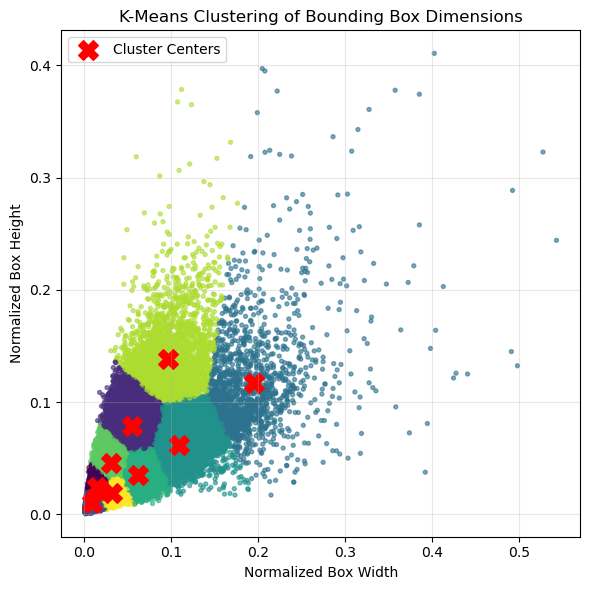

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans

# =========================
# CONFIG
# =========================
IMG_DIR = "/home/zkelias/VisDrone Data/train/images/"
ANN_DIR = "/home/zkelias/VisDrone Data/train/annotations/"
IMAGE_SIZE = 1280

VALID_CLASSES = [1, 2, 3, 4, 5, 6, 9, 10]


# =========================
# LOAD BOX WIDTHS / HEIGHTS
# =========================
def collect_box_wh(img_dir, ann_dir, image_size=800):
    wh_data = []

    image_files = sorted([f for f in os.listdir(img_dir) if f.endswith(".jpg")])

    for img_name in image_files:
        img_path = os.path.join(img_dir, img_name)
        ann_path = os.path.join(ann_dir, img_name.replace(".jpg", ".txt"))

        if not os.path.exists(ann_path) or os.path.getsize(ann_path) == 0:
            continue

        image = Image.open(img_path).convert("RGB")
        w_orig, h_orig = image.size

        scale = image_size / max(w_orig, h_orig)

        with open(ann_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue

                try:
                    row = [float(x) for x in line.split(",")]
                except ValueError:
                    continue

                orig_cls = int(row[5])
                if orig_cls not in VALID_CLASSES:
                    continue

                bw_orig = row[2]
                bh_orig = row[3]

                # same resize logic as your dataset
                bw = (bw_orig * scale) / image_size
                bh = (bh_orig * scale) / image_size

                if bw > 0 and bh > 0:
                    wh_data.append([bw, bh])

    return np.array(wh_data)


# =========================
# RUN K-MEANS
# =========================
def run_kmeans_on_boxes(wh_data, k=9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(wh_data)
    centers = kmeans.cluster_centers_
    return labels, centers


# =========================
# PLOT
# =========================
def plot_anchor_clusters(wh_data, labels, centers, save_path="anchor_clusters.png"):
    plt.figure(figsize=(6, 6))

    # scatter all boxes colored by cluster
    plt.scatter(
        wh_data[:, 0],
        wh_data[:, 1],
        c=labels,
        s=8,
        alpha=0.6
    )

    # plot cluster centers
    plt.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="X",
        s=200,
        c="red",
        label="Cluster Centers"
    )

    plt.xlabel("Normalized Box Width")
    plt.ylabel("Normalized Box Height")
    plt.title("K-Means Clustering of Bounding Box Dimensions")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


# =========================
# PRINT SORTED ANCHORS
# =========================
def print_sorted_anchors(centers):
    areas = centers[:, 0] * centers[:, 1]
    sorted_centers = centers[np.argsort(areas)]

    print("Sorted anchors (small to large):")
    for w, h in sorted_centers:
        print(f"({w:.4f}, {h:.4f})")

    return sorted_centers


# =========================
# MAIN
# =========================
def main():
    wh_data = collect_box_wh(IMG_DIR, ANN_DIR, IMAGE_SIZE)
    print("Collected boxes:", len(wh_data))

    labels, centers = run_kmeans_on_boxes(wh_data, k=9)
    sorted_centers = print_sorted_anchors(centers)

    plot_anchor_clusters(wh_data, labels, centers, save_path="anchor_clusters.png")


if __name__ == "__main__":
    main()

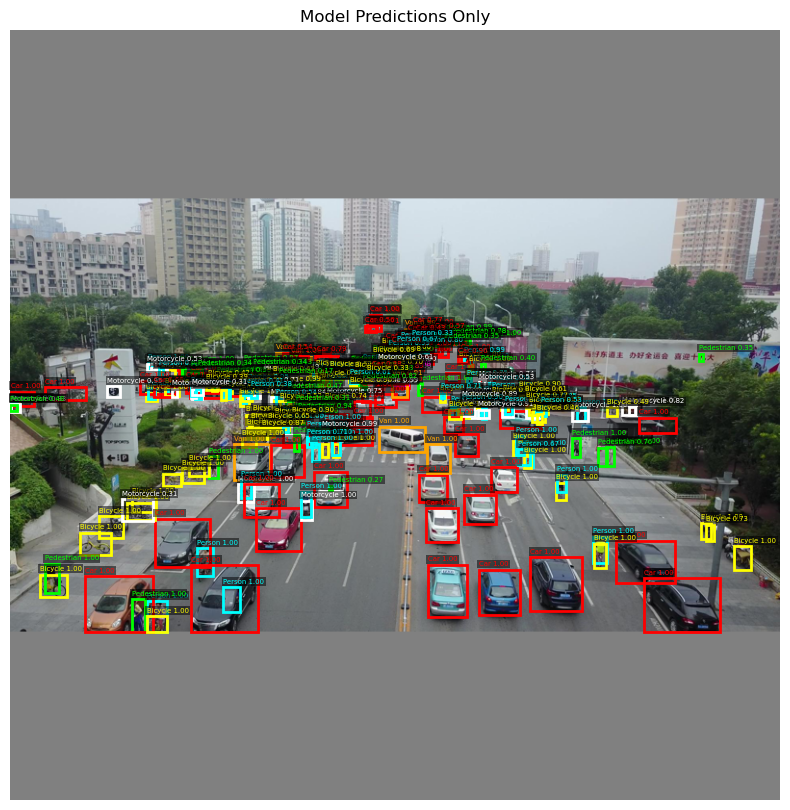

In [29]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# =========================
# CONFIG
# =========================
IMG_PATH = "/home/zkelias/VisDrone Data/train/images/0000136_01783_d_0000157.jpg"

CLASS_NAMES = [
    "Pedestrian", "Person", "Bicycle", "Car",
    "Van", "Truck", "Bus", "Motorcycle"
]

CLASS_COLORS = {
    0: "lime",
    1: "cyan",
    2: "yellow",
    3: "red",
    4: "orange",
    5: "magenta",
    6: "blue",
    7: "white",
}

CONF_THRESH = 0.30
IOU_THRESH = 0.45
IMAGE_SIZE = 800

ANCHORS = torch.tensor([
    [(0.0771, 0.0679), (0.0500, 0.0293), (0.0281, 0.0407)],
    [(0.0279, 0.0164), (0.0157, 0.0257), (0.0093, 0.0179)],
    [(0.0150, 0.0105), (0.0064, 0.0100), (0.0036, 0.0057)]
], dtype=torch.float32).to(DEVICE)

# =========================
# LOAD MODEL
# =========================
model = YOLOv3(num_classes=8).to(DEVICE)

checkpoint = torch.load("/home/zkelias/VisDrone/old.checkpoint.pth.tar", map_location=DEVICE)
model.load_state_dict(checkpoint["state_dict"])

model.eval()

def visualize_model_predictions_only(model, anchors):
    model.eval()

    image = Image.open(IMG_PATH).convert("RGB")
    w_orig, h_orig = image.size

    # same letterbox logic
    scale = IMAGE_SIZE / max(w_orig, h_orig)
    nw, nh = int(w_orig * scale), int(h_orig * scale)

    image_resized = image.resize((nw, nh), Image.Resampling.BICUBIC)
    new_image = Image.new("RGB", (IMAGE_SIZE, IMAGE_SIZE), (128, 128, 128))

    pad_x = (IMAGE_SIZE - nw) // 2
    pad_y = (IMAGE_SIZE - nh) // 2
    new_image.paste(image_resized, (pad_x, pad_y))

    img_np = np.array(new_image)
    img_tensor = torch.from_numpy(img_np.transpose(2, 0, 1)).float() / 255.0
    img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(img_tensor)

    preds = get_nms_predictions(
        outputs,
        batch_idx=0,
        anchors=anchors,
        conf_thresh=CONF_THRESH,
        iou_thresh=IOU_THRESH
    )

    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img_np)

    H, W, _ = img_np.shape

    for p in preds:
        x, y, w, h, score, cls = p
        cls = int(cls)

        x1 = (x - w / 2) * W
        y1 = (y - h / 2) * H
        bw = w * W
        bh = h * H

        color = CLASS_COLORS.get(cls, "red")
        label = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else f"class_{cls}"

        rect = patches.Rectangle(
            (x1, y1),
            bw,
            bh,
            linewidth=2,
            edgecolor=color,
            facecolor='none'
        )
        ax.add_patch(rect)

        ax.text(
            x1,
            max(y1 - 3, 0),
            f"{label} {score:.2f}",
            color=color,
            fontsize=5,
            ha="left",
            va="bottom",
            bbox=dict(facecolor="black", alpha=0.5, pad=1, edgecolor="none")
        )

    plt.title("Model Predictions Only")
    plt.axis("off")
    plt.show()

visualize_model_predictions_only(model, ANCHORS)

In [11]:
import torch
import torchvision.ops as ops
from PIL import Image, ImageDraw
import numpy as np
import os

# --- Configuration ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_SIZE = 1280

CHECKPOINT_PATH = "/home/zkelias/VisDrone/old.checkpoint.pth.tar"
IMAGE_PATH = "/home/zkelias/VisDrone Data/train/images/0000136_01783_d_0000157.jpg"
SAVE_PATH = "/home/zkelias/VisDrone Model Images/check.jpg"

CLASS_NAMES = ["Pedestrian", "People", "Bicycle", "Car", "Van", "Truck", "Bus", "Motorcycle"]
COLORS = ["red", "cyan", "blue", "yellow", "orange", "purple", "magenta", "white"]

anchors = torch.tensor([
    [(0.0771, 0.0679), (0.05, 0.0293), (0.0281, 0.0407)],
    [(0.0279, 0.0164), (0.0157, 0.0257), (0.0093, 0.0179)],
    [(0.0150, 0.0105), (0.0064, 0.0100), (0.0036, 0.0057)]
], dtype=torch.float32).to(DEVICE)

OBJ_THRESH = 0.30
CLS_THRESH = 0.35
NMS_IOU_THRESH = 0.45


def get_letterboxed_img(img_path, size=800):
    img = Image.open(img_path).convert("RGB")
    w_orig, h_orig = img.size

    scale = size / max(w_orig, h_orig)
    nw, nh = int(w_orig * scale), int(h_orig * scale)

    img_resized = img.resize((nw, nh), Image.Resampling.BICUBIC)
    new_image = Image.new("RGB", (size, size), (128, 128, 128))

    pad_x = (size - nw) // 2
    pad_y = (size - nh) // 2
    new_image.paste(img_resized, (pad_x, pad_y))

    return new_image


def draw_label(draw, x1, y1, text, color):
    draw.text((x1, max(0, y1 - 15)), text, fill=color)


# --- Load model ---
model = YOLOv3(num_classes=8).to(DEVICE)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["state_dict"])
model.eval()

# --- Preprocess image ---
image_final = get_letterboxed_img(IMAGE_PATH, IMAGE_SIZE)

img_tensor = torch.from_numpy(np.array(image_final).transpose(2, 0, 1)).float() / 255.0
img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

# --- Run inference ---
with torch.no_grad():
    outputs = model(img_tensor)

raw_preds = []

for scale_idx, out in enumerate(outputs):
    S = out.shape[2]

    obj_probs = torch.sigmoid(out[0, ..., 4])
    class_probs = torch.softmax(out[0, ..., 5:], dim=-1)
    boxes = out[0, ..., 0:4]

    indices = (obj_probs > OBJ_THRESH).nonzero(as_tuple=False)

    for idx in indices:
        a, j, i = idx[0], idx[1], idx[2]

        obj_score = obj_probs[a, j, i].item()
        cls_conf, cls_idx = torch.max(class_probs[a, j, i], dim=-1)

        cls_score = cls_conf.item()
        cls_id = int(cls_idx.item())

        if cls_score < CLS_THRESH:
            continue

        score = obj_score * cls_score

        tx, ty, tw, th = boxes[a, j, i]
        anchor_w, anchor_h = anchors[scale_idx][a]

        x = (torch.sigmoid(tx) + i) / S
        y = (torch.sigmoid(ty) + j) / S
        w = anchor_w * torch.exp(torch.clamp(tw, -10, 10))
        h = anchor_h * torch.exp(torch.clamp(th, -10, 10))

        raw_preds.append([x.item(), y.item(), w.item(), h.item(), score, cls_id])

# --- NMS and draw ---
draw = ImageDraw.Draw(image_final)

if len(raw_preds) > 0:
    preds_tensor = torch.tensor(raw_preds, dtype=torch.float32, device=DEVICE)

    x1 = (preds_tensor[:, 0] - preds_tensor[:, 2] / 2) * IMAGE_SIZE
    y1 = (preds_tensor[:, 1] - preds_tensor[:, 3] / 2) * IMAGE_SIZE
    x2 = (preds_tensor[:, 0] + preds_tensor[:, 2] / 2) * IMAGE_SIZE
    y2 = (preds_tensor[:, 1] + preds_tensor[:, 3] / 2) * IMAGE_SIZE

    boxes_for_nms = torch.stack([x1, y1, x2, y2], dim=1)
    scores = preds_tensor[:, 4]

    final_indices = []

    for cls in range(len(CLASS_NAMES)):
        cls_mask = preds_tensor[:, 5] == cls
        if cls_mask.sum() == 0:
            continue

        cls_boxes = boxes_for_nms[cls_mask]
        cls_scores = scores[cls_mask]

        keep_cls = ops.nms(cls_boxes, cls_scores, NMS_IOU_THRESH)
        original_indices = torch.where(cls_mask)[0][keep_cls]
        final_indices.extend(original_indices.tolist())

    for k in final_indices:
        box = boxes_for_nms[k].tolist()
        cls_id = int(preds_tensor[k, 5].item())
        score = float(preds_tensor[k, 4].item())

        box[0] = max(0, min(IMAGE_SIZE - 1, box[0]))
        box[1] = max(0, min(IMAGE_SIZE - 1, box[1]))
        box[2] = max(0, min(IMAGE_SIZE - 1, box[2]))
        box[3] = max(0, min(IMAGE_SIZE - 1, box[3]))

        color = COLORS[cls_id]
        label = f"{CLASS_NAMES[cls_id]} {score:.2f}"

        draw.rectangle(box, outline=color, width=3)
        draw_label(draw, int(box[0]), int(box[1]), label, color)

# --- Save ---
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
image_final.save(SAVE_PATH)

print(f"Saved result to {SAVE_PATH}")

Saved result to /home/zkelias/VisDrone Model Images/check.jpg
